In [20]:
import numpy as np
import networkx as nx
import time
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from numba import njit
from scipy.stats import gaussian_kde
from scipy.linalg import eigvals
from scipy.linalg import expm
from matplotlib import rc

In [2]:
rc('font',**{'family':'serif','serif':['Times New Roman']})
rc('text', usetex=True)

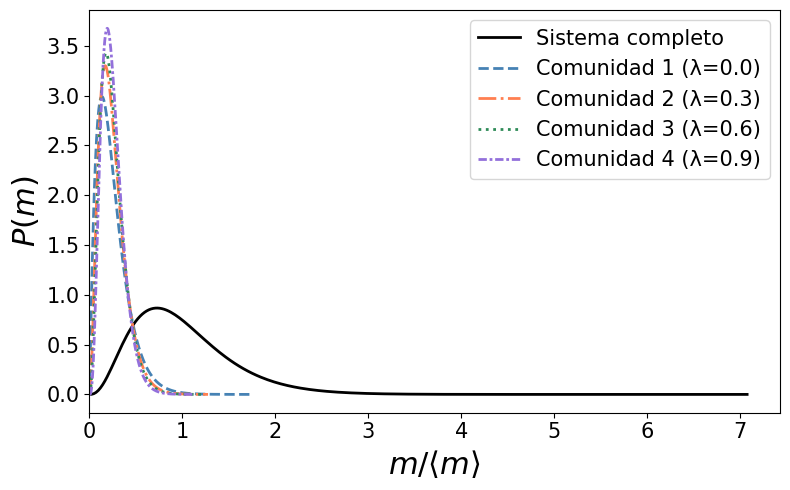

In [24]:
from scipy.stats import gamma
import numpy as np
import matplotlib.pyplot as plt

M = 5e4
N = 500
n_com = N // 4   # 4 comunidades de 125 agentes cada una

lamb1      = 0.0
lamb2      = 0.3
lamb3      = 0.6
lamb4      = 0.9
lamb_inter = np.mean([lamb1, lamb2, lamb3, lamb4])

archivos = {
    f'Sistema completo':           ('Pm_full.npy', N),
    f'Comunidad 1 (λ={lamb1})':    ('Pm_com1.npy', n_com),
    f'Comunidad 2 (λ={lamb2})':    ('Pm_com2.npy', n_com),
    f'Comunidad 3 (λ={lamb3})':    ('Pm_com3.npy', n_com),
    f'Comunidad 4 (λ={lamb4})':    ('Pm_com4.npy', n_com),
}

colors     = ['black', 'steelblue', 'coral', 'seagreen', 'mediumpurple']
linestyles = ['-', '--', '-.', ':', (0, (3, 1, 1, 1))]

fig, ax = plt.subplots(figsize=(8, 5), facecolor="white")

for (label, (archivo, n)), color, ls in zip(archivos.items(), colors, linestyles):
    data = np.load(archivo) / (M/n)
    data_flat = data.flatten()

    alpha, loc, scale = gamma.fit(data_flat, floc=0)

    x_fit = np.linspace(0, data.max(), 300)
    y_fit = gamma.pdf(x_fit, a=alpha, loc=0, scale=scale)

    ax.plot(x_fit, y_fit, color=color, lw=2, linestyle=ls, label=label)

ax.set_xlim(left=0)
ax.set_xlabel(r'$m/\langle m \rangle$', fontsize=22)
ax.set_ylabel(r'$P(m)$', fontsize=22)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
ax.legend(fontsize=15)
plt.tight_layout()
plt.savefig('Comunidades.pdf', bbox_inches='tight')
plt.show()

1: α=2.9440, θ=0.3397, media=1.0000, KS=0.0047, p=0.0000
2: α=3.0625, θ=0.3265, media=1.0000, KS=0.0079, p=0.0000


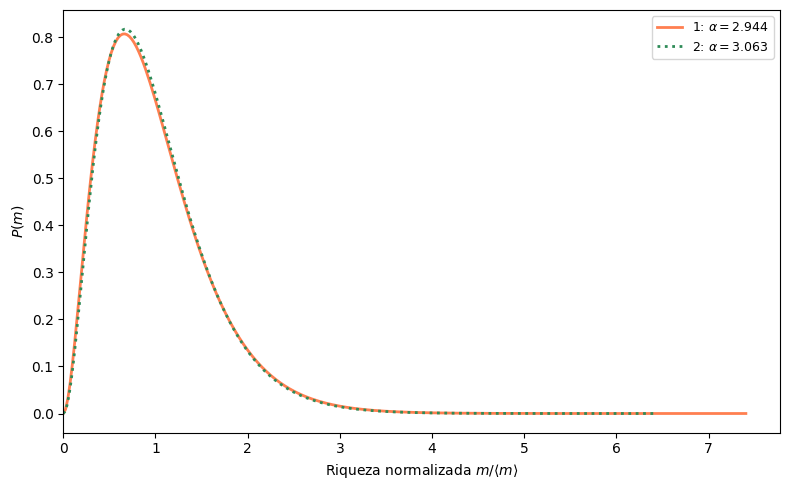

In [39]:
from scipy.stats import gamma, kstest
import numpy as np
import matplotlib.pyplot as plt

M = 5e4
N = 500

datasets = {
    '1':      np.load('Pm_full.npy') / (M/N),
    '2':      np.load('../Normal/Comunities/Pm_lamb0.4.npy') / (M/N),
}

colors     = ['coral', 'seagreen']
linestyles = ['-', ':']

fig, ax = plt.subplots(figsize=(8, 5))

for (label, data), color, ls in zip(datasets.items(), colors, linestyles):
    data_flat = data.flatten()
    alpha, loc, scale = gamma.fit(data_flat, floc=0)

    x_fit = np.linspace(0, data.max(), 300)
    y_fit = gamma.pdf(x_fit, a=alpha, loc=0, scale=scale)

    ax.plot(x_fit, y_fit, color=color, lw=2, linestyle=ls,
            label=fr'{label}: $\alpha={alpha:.3f}$')

    stat, p = kstest(data_flat, 'gamma', args=(alpha, 0, scale))
    print(f"{label}: α={alpha:.4f}, θ={scale:.4f}, media={alpha*scale:.4f}, KS={stat:.4f}, p={p:.4f}")

ax.set_xlim(left=0)
ax.set_xlabel('Riqueza normalizada $m/\\langle m \\rangle$')
ax.set_ylabel('$P(m)$')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()